# Importing

## Import Library

In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/manav0negi/student-performance-mock-dataindian-edition/Student_Analysis.csv


## Import CSV And convert to DataFrame

In [19]:
df = pd.read_csv('/kaggle/input/datasets/manav0negi/student-performance-mock-dataindian-edition/Student_Analysis.csv')

# Preprocessing

## Frist five row

In [20]:
df.head()

,University-ID,Name,Gender,Course,Brach,Age,Marks(%),Pass/Fail,Grade,Attendance(%),Hostel/Day Scholar
0,2027-0001,Anita Chundawat,Female,Bcom,NaN,21,65,Pass,C,64,Hostel
1,2027-0002,Vijay Mankotia,Male,BCom,NaN,20,73,Pass,B,89,Day Scholar
2,2027-0003,Jyoti Aswal,Female,BCom,NaN,20,79,Pass,B,78,Hostel
3,2027-0004,Chandan Panwar,Male,BBA,NaN,19,82,Pass,A,66,Day Scholar
4,2027-0005,Shashi Hegde,Male,B-Tech,EE,19,77,Pass,B,98,Day Scholar


## last Five row

In [21]:
df.tail()

,University-ID,Name,Gender,Course,Brach,Age,Marks(%),Pass/Fail,Grade,Attendance(%),Hostel/Day Scholar
1995,2027-1996,Priya Iyer,Female,BCom,NaN,21,70,Pass,B,66,Day Scholar
1996,2027-1997,Nisha Semwal,Female,BCom,NaN,20,79,Pass,B,68,Day Scholar
1997,2027-1998,Harleen Grewal,Female,B-Tech,CE,19,64,Pass,C,84,Day Scholar
1998,2027-1999,Harpreet Sidhu,Male,BCA,NaN,20,64,Pass,C,87,Hostel
1999,2027-2000,Netra Bhat,Female,BCA,NaN,20,82,Pass,A,92,Day Scholar


## Shape of our dataset

In [22]:
df.shape

(2000, 11)

## List out all columns

In [23]:
df.columns

Index(['University-ID', 'Name', 'Gender', 'Course', 'Brach', 'Age', 'Marks(%)',
       'Pass/Fail', 'Grade', 'Attendance(%)', 'Hostel/Day Scholar'],
      dtype='object')

## Datatype of each columns

In [24]:
df.dtypes

University-ID         object
Name                  object
Gender                object
Course                object
Brach                 object
Age                    int64
Marks(%)               int64
Pass/Fail             object
Grade                 object
Attendance(%)          int64
Hostel/Day Scholar    object
dtype: object

## Information of all Columns

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   University-ID       2000 non-null   object
 1   Name                2000 non-null   object
 2   Gender              2000 non-null   object
 3   Course              2000 non-null   object
 4   Brach               778 non-null    object
 5   Age                 2000 non-null   int64 
 6   Marks(%)            2000 non-null   int64 
 7   Pass/Fail           2000 non-null   object
 8   Grade               2000 non-null   object
 9   Attendance(%)       2000 non-null   int64 
 10  Hostel/Day Scholar  2000 non-null   object
dtypes: int64(3), object(8)
memory usage: 172.0+ KB


## Check Null Value

In [26]:
df.isnull().sum()

University-ID            0
Name                     0
Gender                   0
Course                   0
Brach                 1222
Age                      0
Marks(%)                 0
Pass/Fail                0
Grade                    0
Attendance(%)            0
Hostel/Day Scholar       0
dtype: int64

## Drop Null Feathers

In [27]:
df.drop('Brach', axis=1, inplace=True)

## Check Dupicate Value

In [28]:
df.duplicated().sum()

np.int64(0)

## Summary

In [29]:
df.describe()

,Age,Marks(%),Attendance(%)
count,2000.000000,2000.000000,2000.000000
mean,19.999500,65.121500,78.836000
std,0.827552,11.910528,11.210484
min,19.000000,28.000000,60.000000
25%,19.000000,57.000000,69.000000
50%,20.000000,65.000000,79.000000
75%,21.000000,73.000000,88.250000
max,23.000000,100.000000,98.000000


# EDA

In [30]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

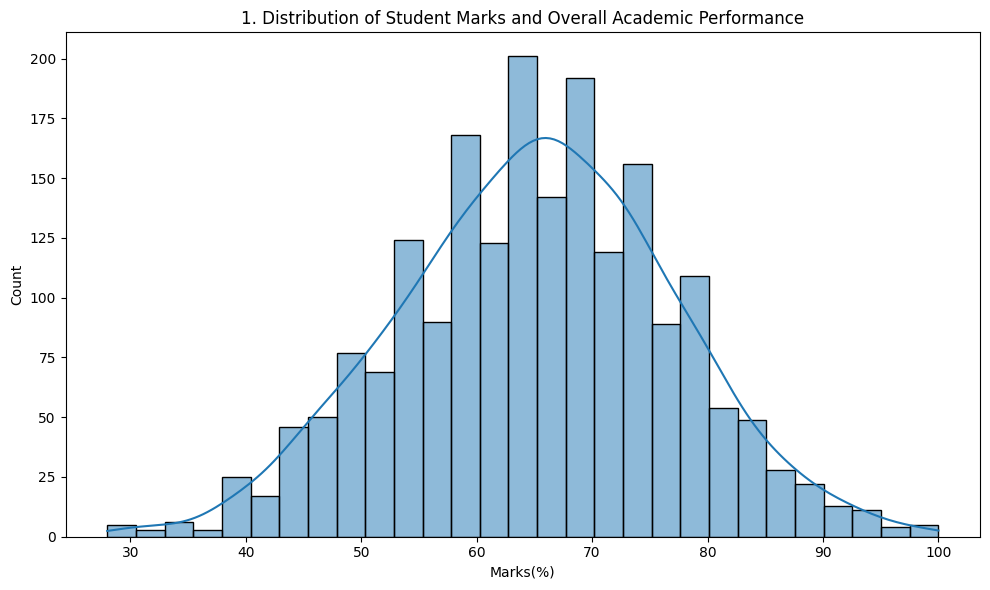

In [31]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Marks(%)', kde=True)
plt.title(f'{plot_no}. Distribution of Student Marks and Overall Academic Performance')
show_fig()
plot_no += 1

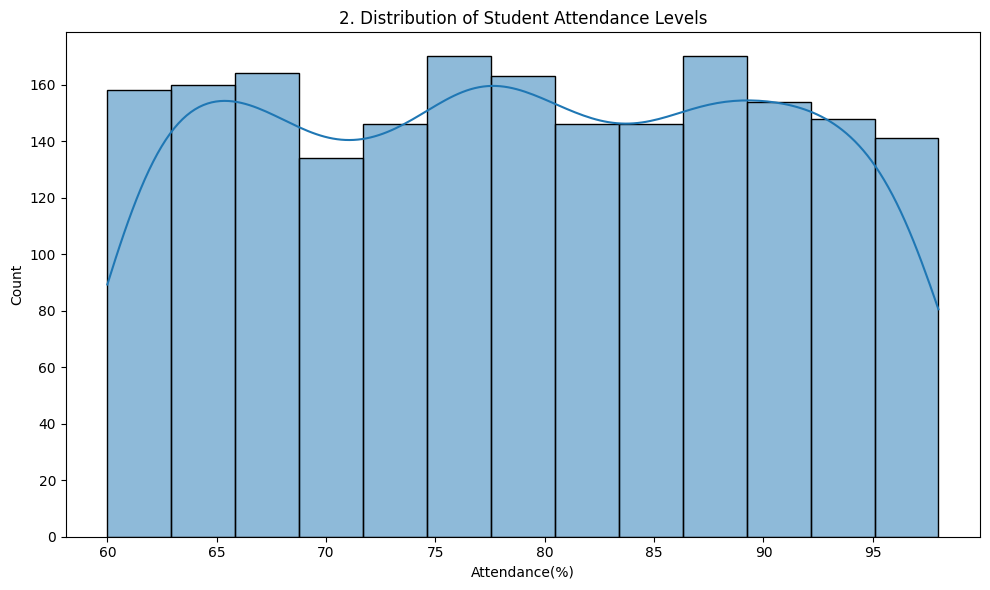

In [32]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Attendance(%)', kde=True)
plt.title(f'{plot_no}. Distribution of Student Attendance Levels')
show_fig()
plot_no += 1

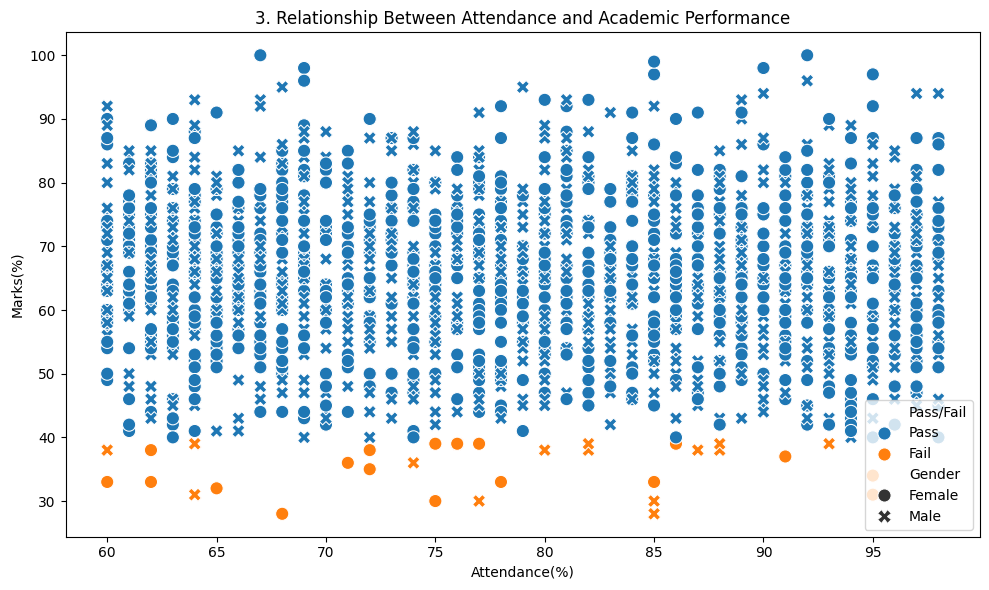

In [33]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Attendance(%)', y='Marks(%)', hue='Pass/Fail', style='Gender', s=90)
plt.title(f'{plot_no}. Relationship Between Attendance and Academic Performance')
show_fig()
plot_no += 1

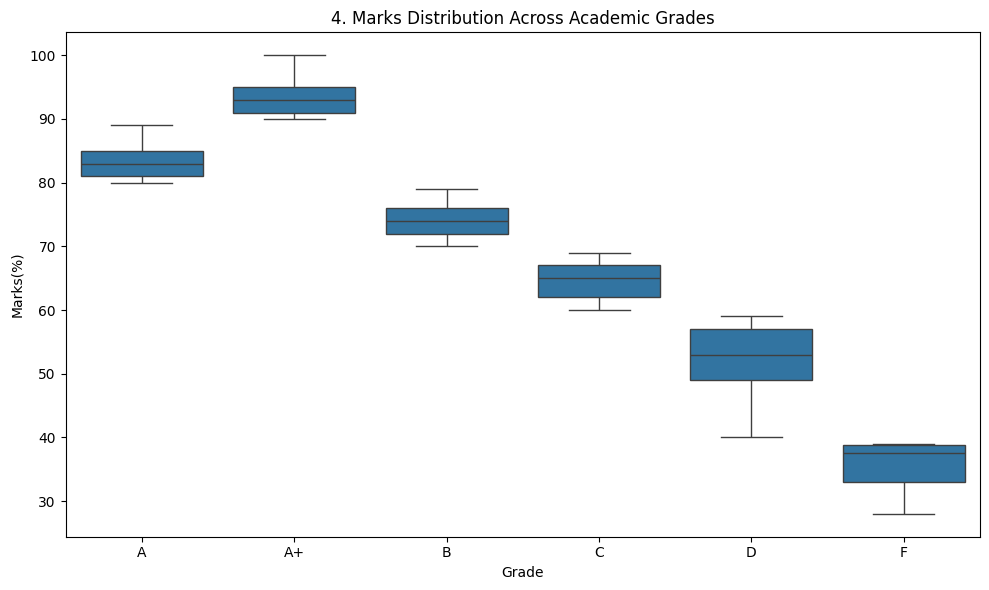

In [34]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Grade', y='Marks(%)', order=sorted(df['Grade'].dropna().unique()))
plt.title(f'{plot_no}. Marks Distribution Across Academic Grades')
show_fig()
plot_no += 1

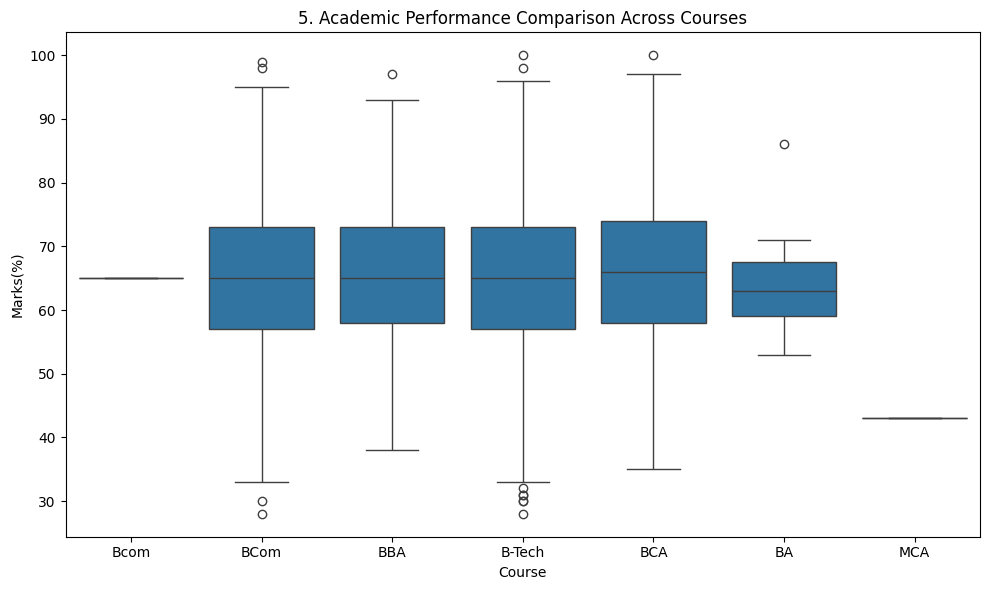

In [35]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Course', y='Marks(%)')
plt.title(f'{plot_no}. Academic Performance Comparison Across Courses')
show_fig()
plot_no += 1

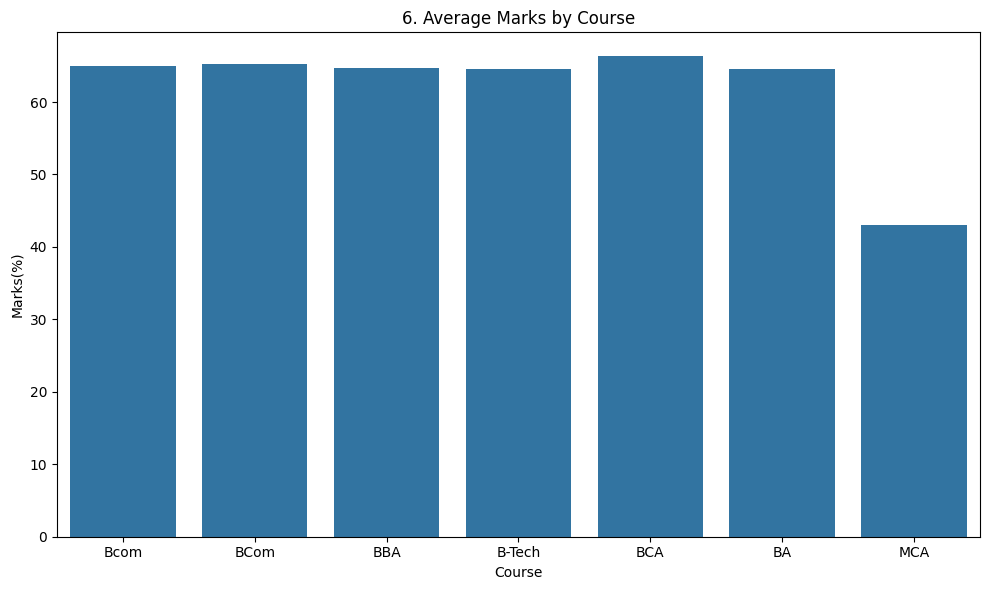

In [36]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Course', y='Marks(%)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Marks by Course')
show_fig()
plot_no += 1

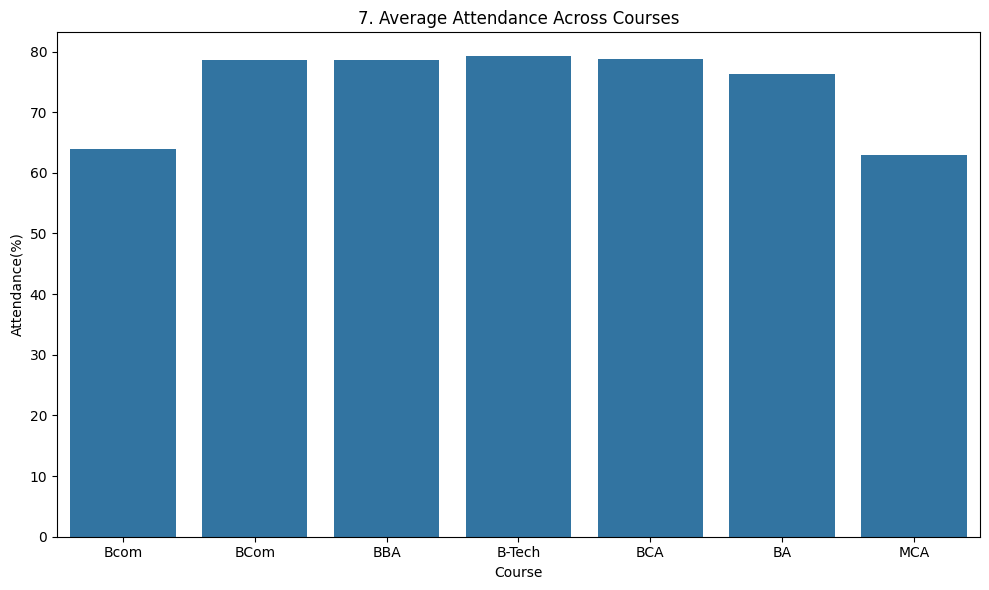

In [37]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Course', y='Attendance(%)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Attendance Across Courses')
show_fig()
plot_no += 1

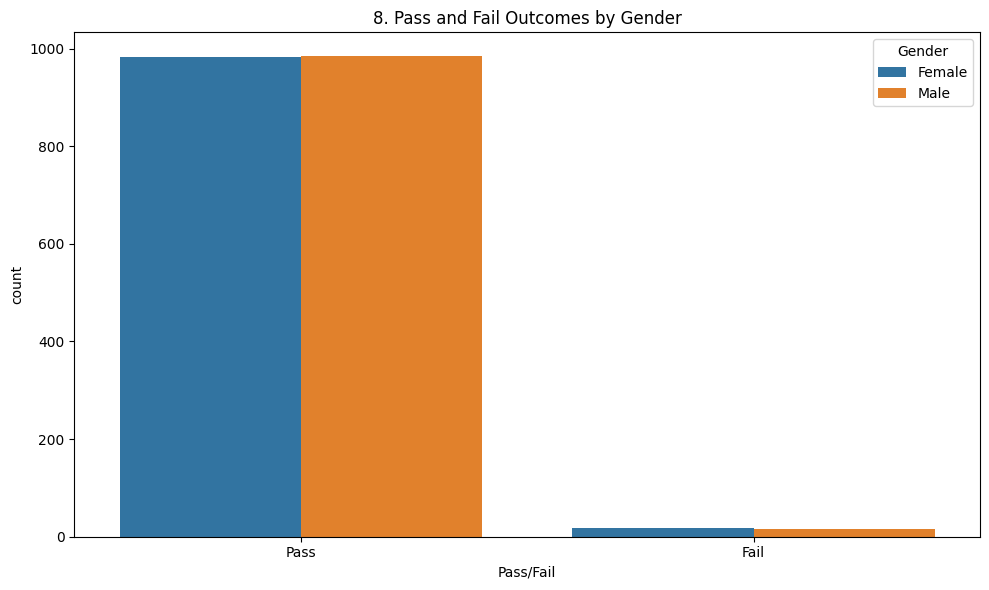

In [38]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pass/Fail', hue='Gender')
plt.title(f'{plot_no}. Pass and Fail Outcomes by Gender')
show_fig()
plot_no += 1

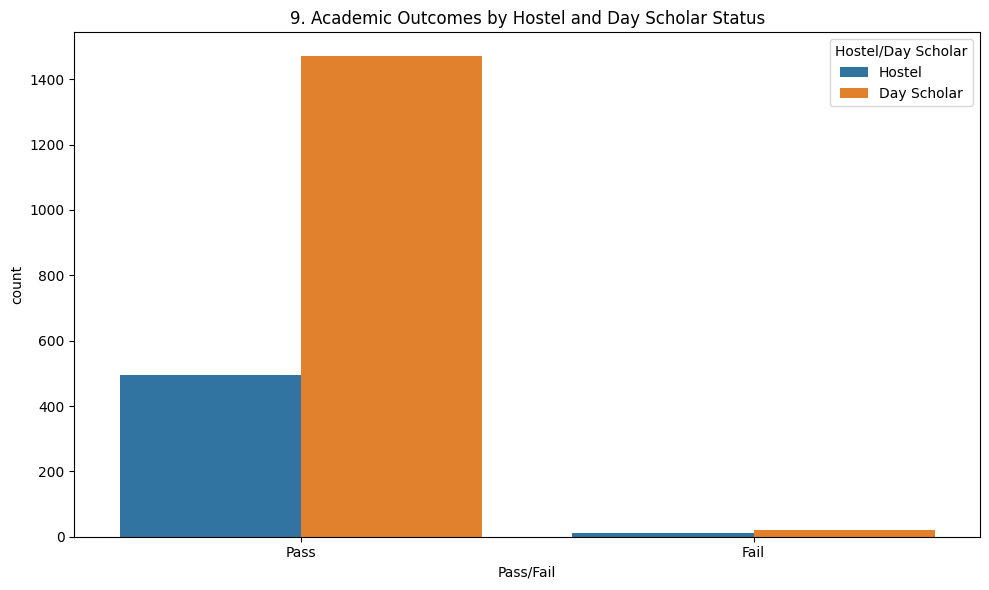

In [39]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pass/Fail', hue='Hostel/Day Scholar')
plt.title(f'{plot_no}. Academic Outcomes by Hostel and Day Scholar Status')
show_fig()
plot_no += 1

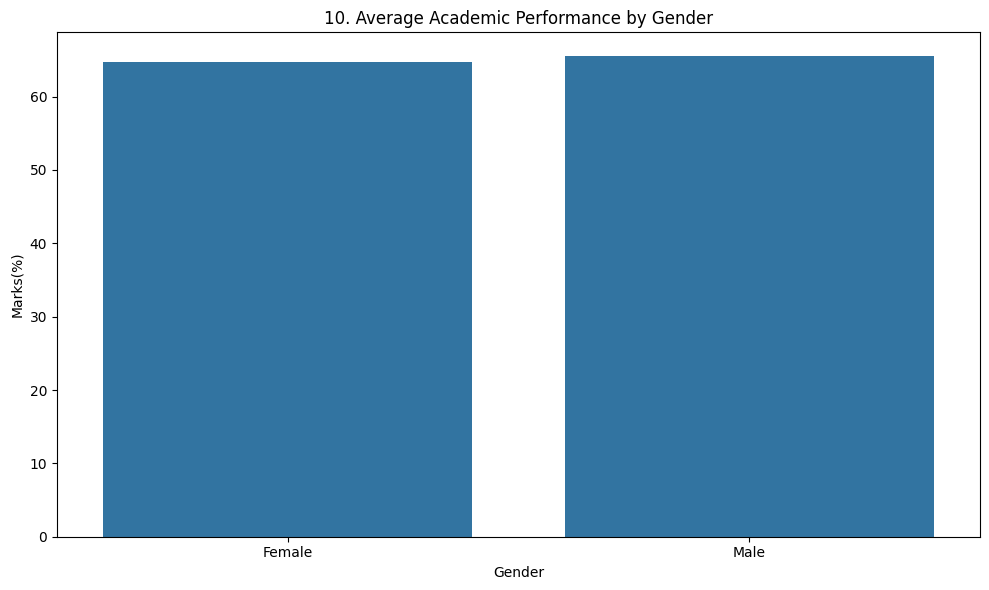

In [40]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Gender', y='Marks(%)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Academic Performance by Gender')
show_fig()
plot_no += 1

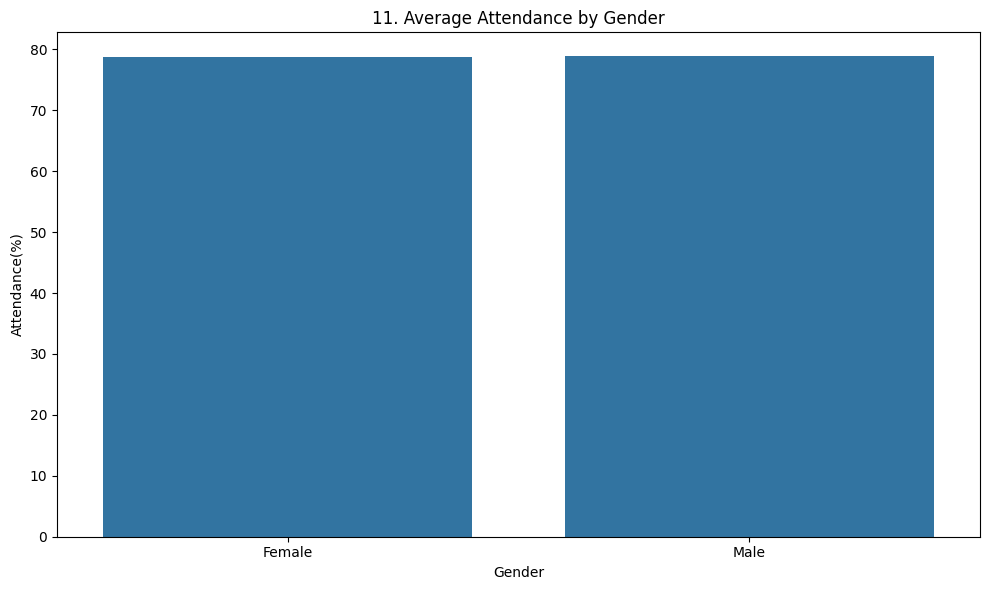

In [41]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Gender', y='Attendance(%)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Attendance by Gender')
show_fig()
plot_no += 1

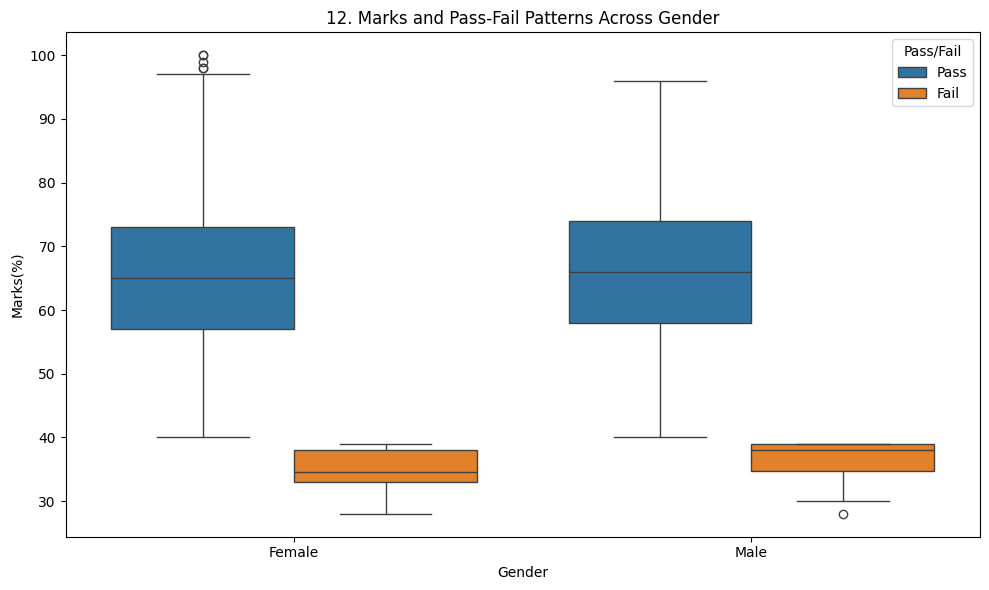

In [42]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Gender', y='Marks(%)', hue='Pass/Fail')
plt.title(f'{plot_no}. Marks and Pass-Fail Patterns Across Gender')
show_fig()
plot_no += 1

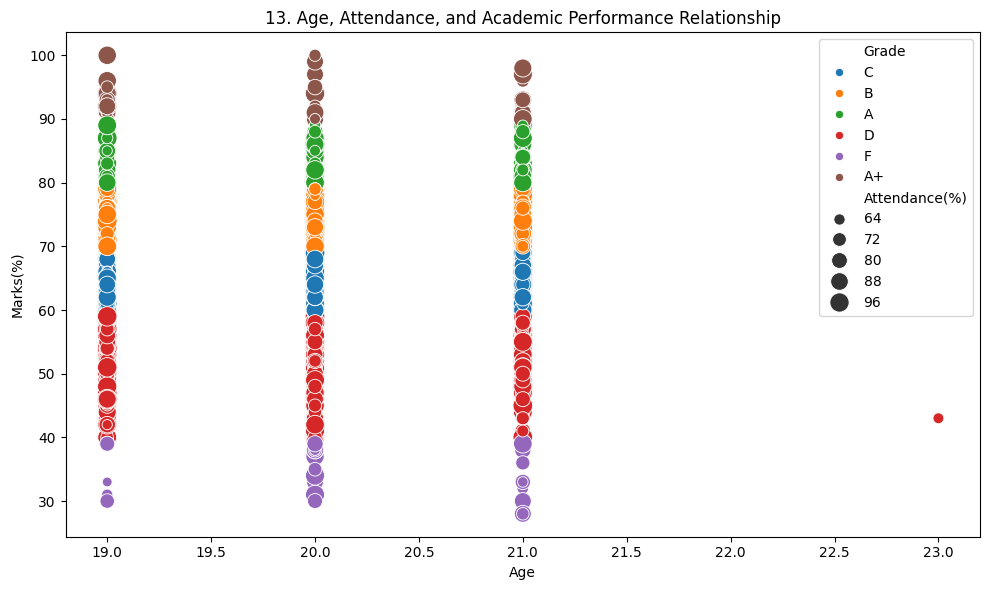

In [43]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Marks(%)', hue='Grade', size='Attendance(%)', sizes=(50,200))
plt.title(f'{plot_no}. Age, Attendance, and Academic Performance Relationship')
show_fig()
plot_no += 1

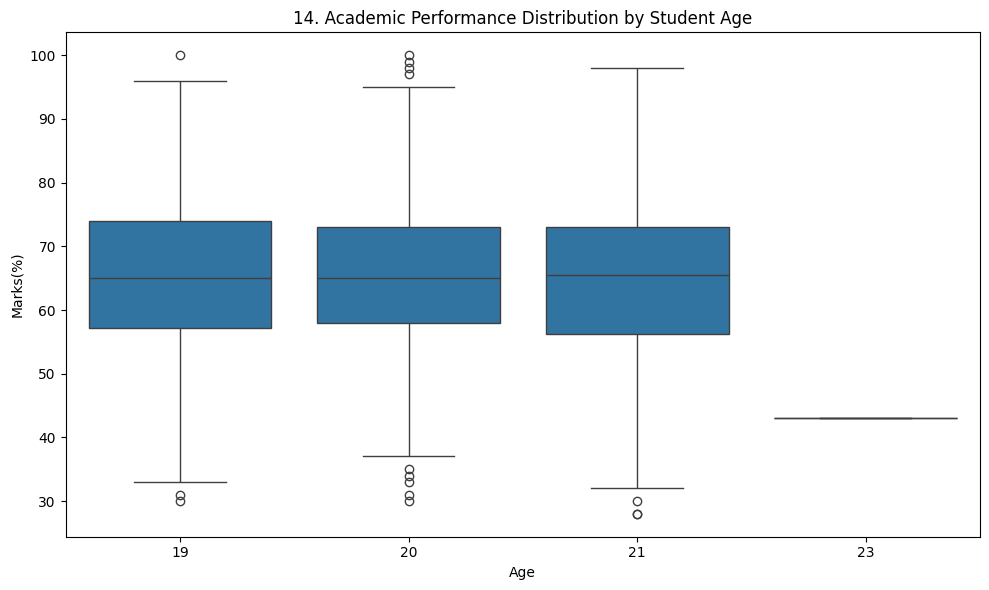

In [44]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Age', y='Marks(%)')
plt.title(f'{plot_no}. Academic Performance Distribution by Student Age')
show_fig()
plot_no += 1

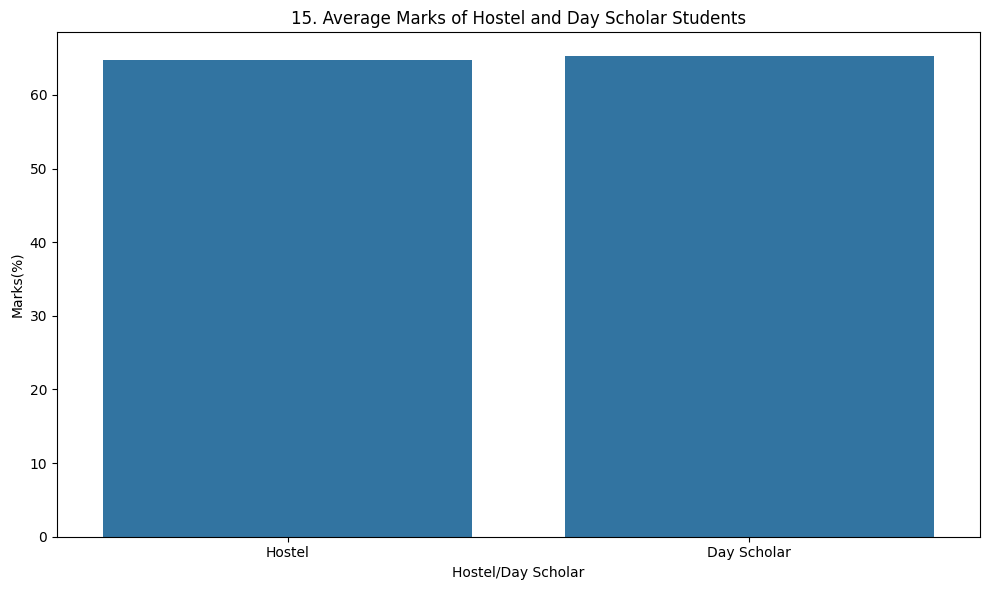

In [45]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Hostel/Day Scholar', y='Marks(%)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Marks of Hostel and Day Scholar Students')
show_fig()
plot_no += 1

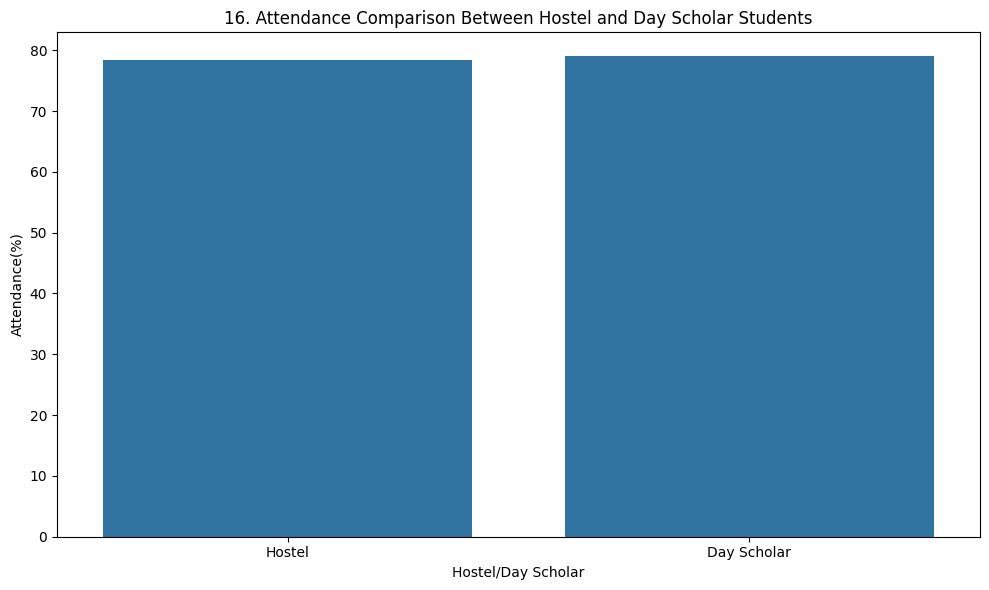

In [46]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Hostel/Day Scholar', y='Attendance(%)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Attendance Comparison Between Hostel and Day Scholar Students')
show_fig()
plot_no += 1

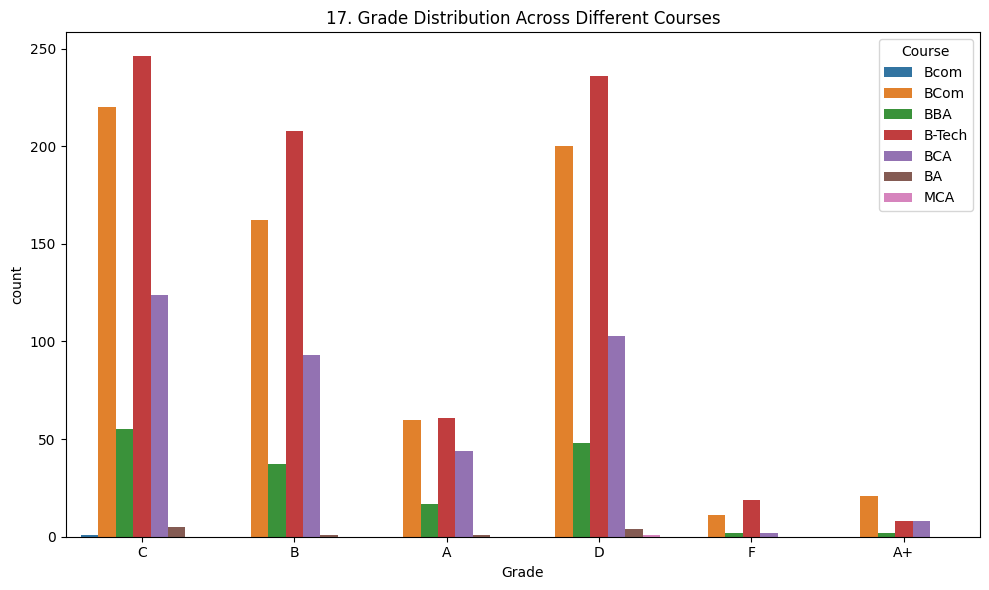

In [47]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Grade', hue='Course')
plt.title(f'{plot_no}. Grade Distribution Across Different Courses')
show_fig()
plot_no += 1

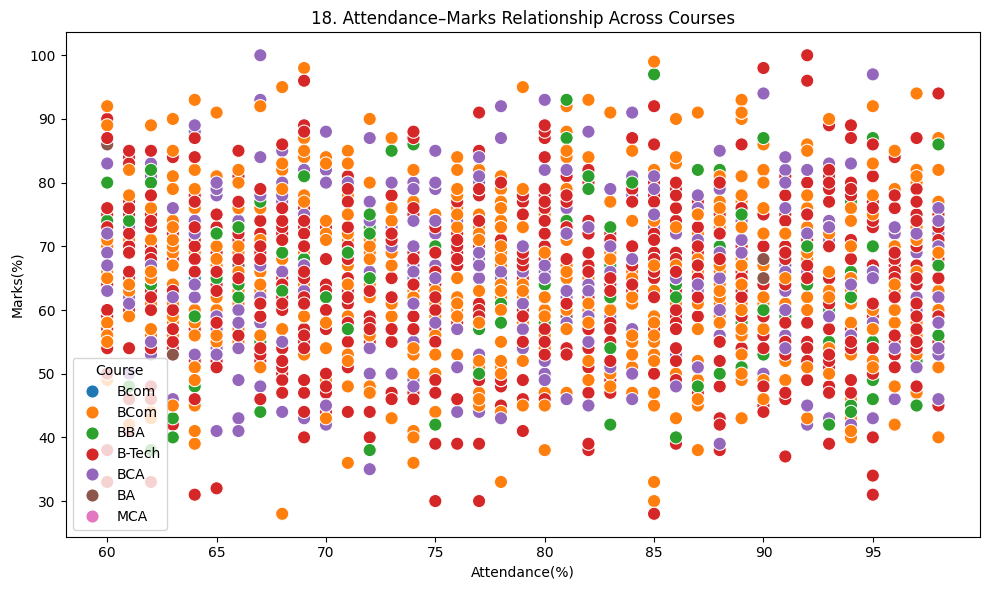

In [48]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Attendance(%)', y='Marks(%)', hue='Course', s=90)
plt.title(f'{plot_no}. Attendance–Marks Relationship Across Courses')
show_fig()
plot_no += 1

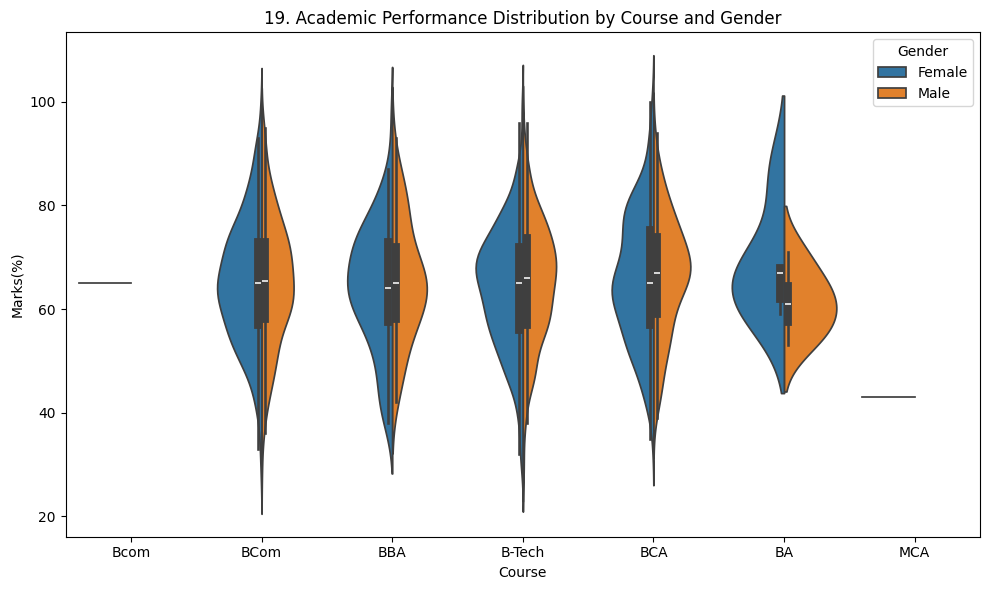

In [49]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Course', y='Marks(%)', hue='Gender', split=True)
plt.title(f'{plot_no}. Academic Performance Distribution by Course and Gender')
show_fig()
plot_no += 1

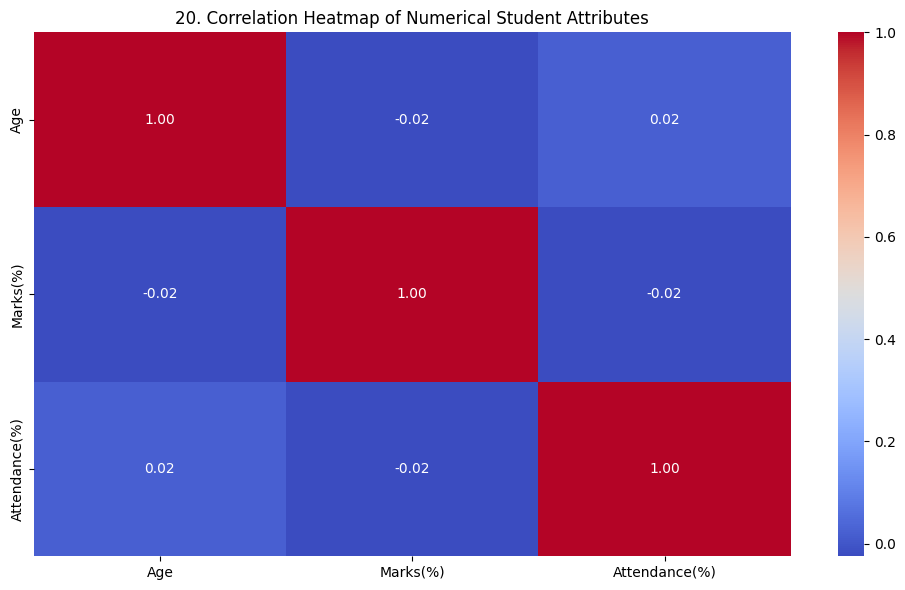

In [50]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Student Attributes')
show_fig()
plot_no += 1